In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
apps = pd.read_csv('apps.csv')
reviews = pd.read_csv('user_reviews.csv')

print(apps.shape)
print(reviews.shape)

apps.head()
reviews.head()

(9659, 14)
(64295, 5)


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [43]:
apps = apps.copy()

# Clean Size (PUT HERE 👇)
def clean_size(size):
    if isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M',''))
        elif 'k' in size:
            return float(size.replace('k','')) / 1024
        else:
            return np.nan
    return np.nan

apps['Size'] = apps['Size'].apply(clean_size)

In [46]:
apps = apps.copy()

# Remove invalid ratings
apps = apps[apps['Rating'] <= 5]

# Reviews column
apps['Reviews'] = apps['Reviews'].astype(str).str.replace(',', '')
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')

# Installs
apps['Installs'] = apps['Installs'].astype(str)
apps['Installs'] = apps['Installs'].str.replace('+','', regex=False)
apps['Installs'] = apps['Installs'].str.replace(',','', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

# Price
apps['Price'] = apps['Price'].astype(str)
apps['Price'] = apps['Price'].str.replace('$','', regex=False)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')


In [47]:
apps.fillna({
    'Rating': apps['Rating'].median(),
    'Type': 'Free',
    'Content Rating': 'Everyone'
}, inplace=True)

In [49]:
reviews = reviews.copy()

reviews = reviews.dropna(subset=['Translated_Review'])

reviews['Sentiment'] = reviews['Sentiment'].fillna('Neutral')

In [50]:
merged_df = pd.merge(apps, reviews, on='App', how='inner')

print(merged_df.shape)
merged_df.head()

(35929, 18)


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
2,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
3,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000
4,1,Coloring book moana,ART_AND_DESIGN,3.9,967,NaN,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I hate,Negative,-0.800,0.900000


In [32]:
merged_df.info()
merged_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35929 entries, 0 to 35928
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              35929 non-null  int64  
 1   App                     35929 non-null  object 
 2   Category                35929 non-null  object 
 3   Rating                  35929 non-null  float64
 4   Reviews                 35929 non-null  int64  
 5   Size                    24069 non-null  float64
 6   Installs                35929 non-null  int64  
 7   Type                    35929 non-null  object 
 8   Price                   35929 non-null  float64
 9   Content Rating          35929 non-null  object 
 10  Genres                  35929 non-null  object 
 11  Last Updated            35929 non-null  object 
 12  Current Ver             35929 non-null  object 
 13  Android Ver             35929 non-null  object 
 14  Translated_Review       35929 non-null

,Unnamed: 0,Rating,Reviews,Size,Installs,Price,Sentiment_Polarity,Sentiment_Subjectivity
count,35929.000000,35929.000000,3.592900e+04,24069.000000,3.592900e+04,35929.000000,35929.000000,35929.000000
mean,2035.911659,4.297197,1.413699e+06,29.362533,4.377751e+07,0.109197,0.180904,0.493767
std,1175.355776,0.303176,5.733496e+06,26.197106,1.453414e+08,1.302471,0.350080,0.258053
min,1.000000,2.600000,1.140000e+02,0.000000,1.000000e+03,0.000000,-1.000000,0.000000
25%,1189.000000,4.100000,1.024700e+04,9.100000,1.000000e+06,0.000000,0.000000,0.361111
50%,1824.000000,4.300000,6.451300e+04,20.000000,5.000000e+06,0.000000,0.150000,0.514835
75%,3102.000000,4.500000,5.156570e+05,45.000000,1.000000e+07,0.000000,0.400000,0.650000
max,9862.000000,4.900000,7.815831e+07,99.000000,1.000000e+09,29.990000,1.000000,1.000000


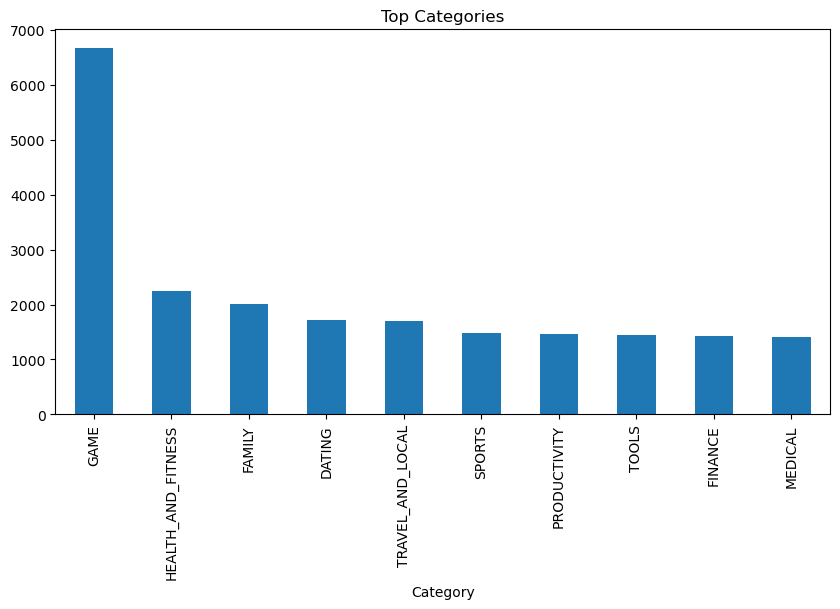

In [33]:
plt.figure(figsize=(10,5))
merged_df['Category'].value_counts().head(10).plot(kind='bar')
plt.title("Top Categories")
plt.show()

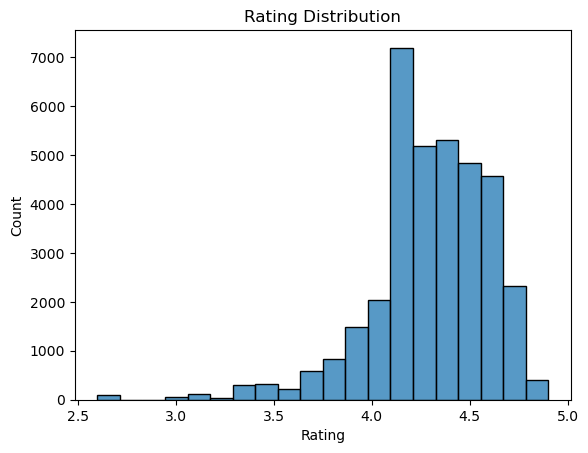

In [34]:
sns.histplot(merged_df['Rating'], bins=20)
plt.title("Rating Distribution")
plt.show()

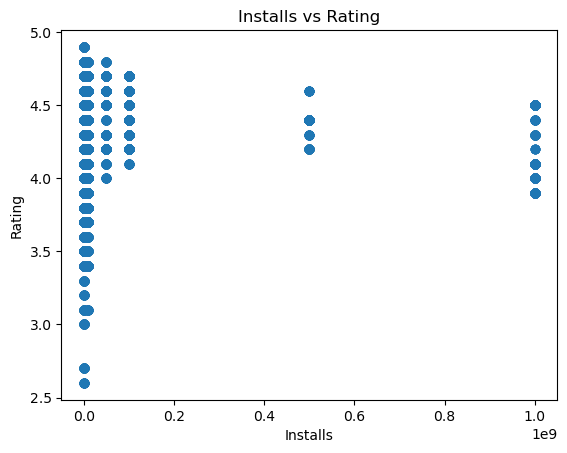

In [35]:
plt.scatter(merged_df['Installs'], merged_df['Rating'])
plt.xlabel("Installs")
plt.ylabel("Rating")
plt.title("Installs vs Rating")
plt.show()

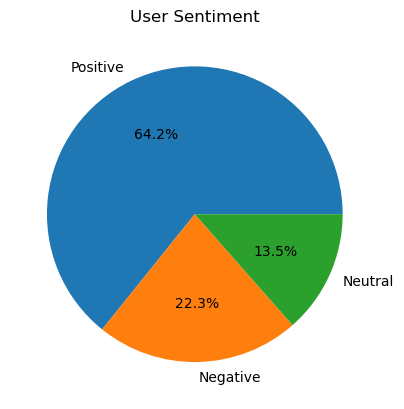

In [36]:
sentiment_counts = merged_df['Sentiment'].value_counts()

plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("User Sentiment")
plt.show()

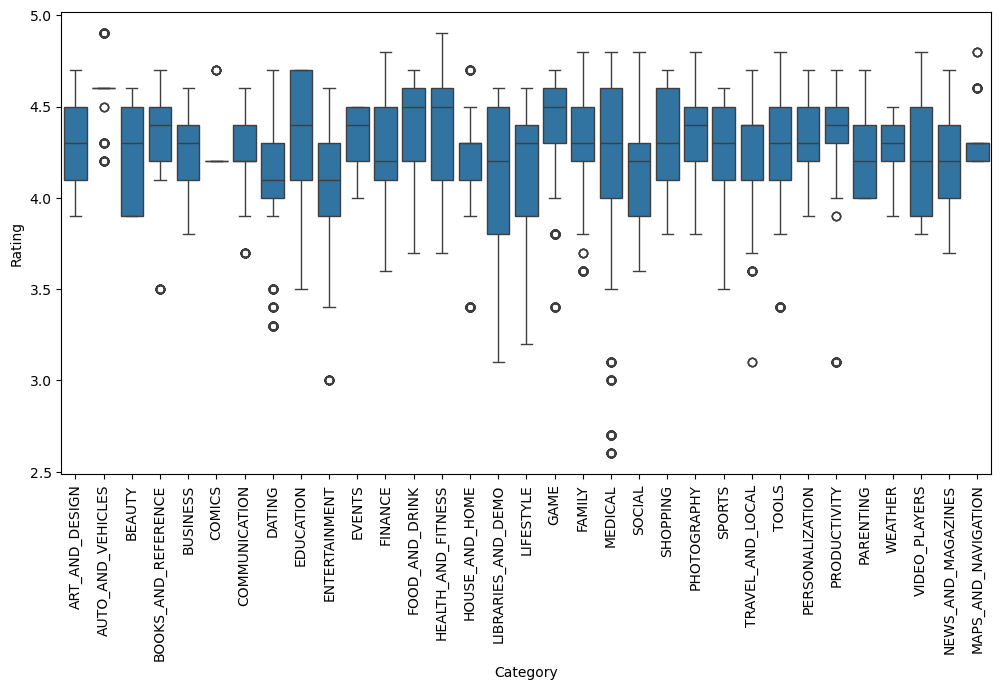

In [37]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Category', y='Rating', data=merged_df)
plt.xticks(rotation=90)
plt.show()

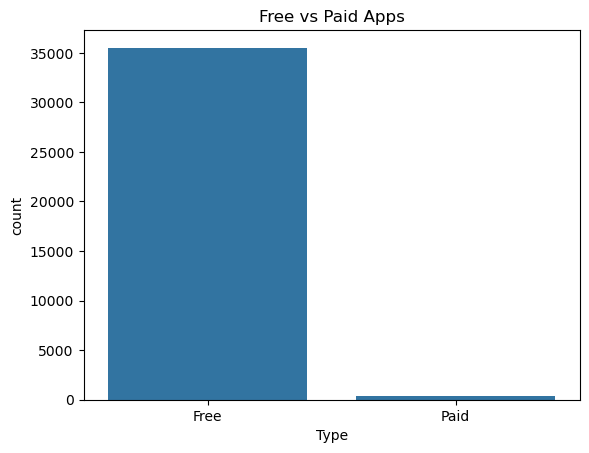

In [38]:
sns.countplot(x='Type', data=merged_df)
plt.title("Free vs Paid Apps")
plt.show()

In [39]:
top_apps = merged_df.sort_values(by='Installs', ascending=False).head(10)

print(top_apps[['App','Installs','Rating','Sentiment']])

          App    Installs  Rating Sentiment
28581  Google  1000000000     4.4  Positive
28582  Google  1000000000     4.4  Positive
28583  Google  1000000000     4.4  Positive
28584  Google  1000000000     4.4  Positive
28585  Google  1000000000     4.4  Positive
28586  Google  1000000000     4.4  Positive
28587  Google  1000000000     4.4  Negative
28588  Google  1000000000     4.4  Negative
28589  Google  1000000000     4.4  Positive
28565  Google  1000000000     4.4  Positive


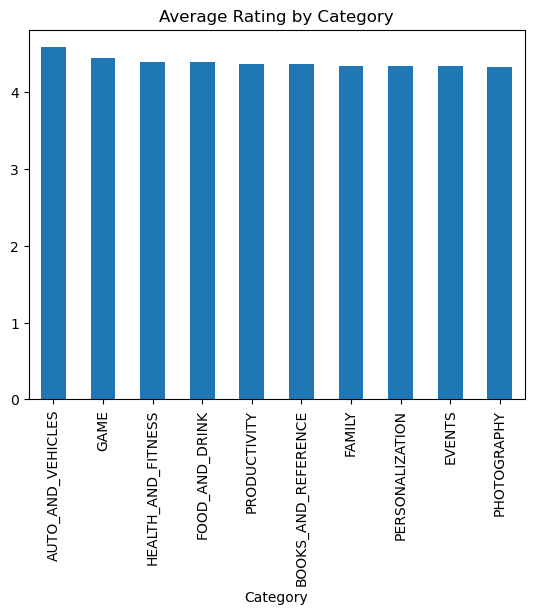

In [40]:
category_rating = merged_df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

category_rating.head(10).plot(kind='bar')
plt.title("Average Rating by Category")
plt.show()

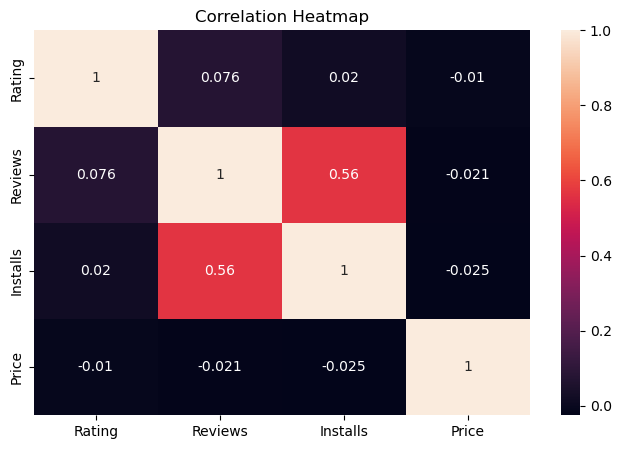

In [41]:
plt.figure(figsize=(8,5))
sns.heatmap(merged_df[['Rating','Reviews','Installs','Price']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [42]:
print("Average Rating:", merged_df['Rating'].mean())
print("Most Popular Category:", merged_df['Category'].value_counts().idxmax())
print("Most Common Sentiment:", merged_df['Sentiment'].value_counts().idxmax())
print("Free Apps %:", (merged_df['Type'].value_counts(normalize=True)['Free'])*100)

Average Rating: 4.297197250132205
Most Popular Category: GAME
Most Common Sentiment: Positive
Free Apps %: 98.84216092849786
